# AG News LSTM vs Transformer Encoder

This notebook compares an LSTM classifier and a Transformer Encoder classifier trained from scratch on the AG News text classification task. The official test split is reserved for final evaluation only.

## 1. Setup And Reproducibility

In [1]:
import random
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from datasets import load_dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset

SEED = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 2. Load Dataset

In [2]:
raw_dataset = load_dataset("fancyzhx/ag_news")
split_dataset = raw_dataset["train"].train_test_split(test_size=0.1, seed=SEED)

train_data = split_dataset["train"]
valid_data = split_dataset["test"]
test_data = raw_dataset["test"]

label_names = raw_dataset["train"].features["label"].names
label_names

['World', 'Sports', 'Business', 'Sci/Tech']

## 3. Inspect Labels And Splits

In [3]:
split_summary = pd.DataFrame(
    {
        "split": ["train", "valid", "test"],
        "samples": [len(train_data), len(valid_data), len(test_data)],
    }
)

all_labels = set(train_data["label"]) | set(valid_data["label"]) | set(test_data["label"])
assert all_labels == {0, 1, 2, 3}, all_labels
split_summary

,split,samples
0,train,108000
1,valid,12000
2,test,7600


In [4]:
def label_distribution(hf_dataset, split_name: str) -> pd.DataFrame:
    counts = Counter(hf_dataset["label"])
    rows = []
    for label_idx, label_name in enumerate(label_names):
        rows.append(
            {
                "split": split_name,
                "label": label_idx,
                "label_name": label_name,
                "count": counts[label_idx],
                "percent": counts[label_idx] / len(hf_dataset),
            }
        )
    return pd.DataFrame(rows)

class_distribution = pd.concat(
    [
        label_distribution(train_data, "train"),
        label_distribution(valid_data, "valid"),
        label_distribution(test_data, "test"),
    ],
    ignore_index=True,
)
class_distribution

,split,label,label_name,count,percent
0,train,0,World,26991,0.249917
1,train,1,Sports,26966,0.249685
2,train,2,Business,27100,0.250926
3,train,3,Sci/Tech,26943,0.249472
4,valid,0,World,3009,0.250750
5,valid,1,Sports,3034,0.252833
6,valid,2,Business,2900,0.241667
7,valid,3,Sci/Tech,3057,0.254750
8,test,0,World,1900,0.250000
9,test,1,Sports,1900,0.250000


## 4. Tokenization And Vocabulary

In [5]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_IDX = 0
UNK_IDX = 1
VOCAB_SIZE = 20_000
MAX_LEN = 128

TOKEN_RE = re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?")

def tokenize(text: str) -> list[str]:
    return TOKEN_RE.findall(text.lower())

def build_vocab(texts, vocab_size: int = VOCAB_SIZE) -> tuple[list[str], dict[str, int]]:
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    most_common = counter.most_common(vocab_size - 2)
    itos = [PAD_TOKEN, UNK_TOKEN] + [token for token, _ in most_common]
    stoi = {token: idx for idx, token in enumerate(itos)}
    return itos, stoi

itos, stoi = build_vocab(train_data["text"])

def encode(text: str, stoi: dict[str, int], max_len: int = MAX_LEN) -> tuple[list[int], list[int]]:
    ids = [stoi.get(token, UNK_IDX) for token in tokenize(text)]
    ids = ids[:max_len]
    attention_mask = [1] * len(ids)
    pad_count = max_len - len(ids)
    if pad_count > 0:
        ids = ids + [PAD_IDX] * pad_count
        attention_mask = attention_mask + [0] * pad_count
    return ids, attention_mask

assert itos[PAD_IDX] == PAD_TOKEN
assert itos[UNK_IDX] == UNK_TOKEN
assert len(itos) <= VOCAB_SIZE
sample_ids, sample_mask = encode(train_data[0]["text"], stoi)
assert len(sample_ids) == MAX_LEN
assert len(sample_mask) == MAX_LEN
len(itos)

20000

## 5. Dataset And DataLoader

In [6]:
class AGNewsTorchDataset(Dataset):
    def __init__(self, hf_dataset, stoi: dict[str, int], max_len: int = MAX_LEN):
        self.texts = hf_dataset["text"]
        self.labels = hf_dataset["label"]
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict:
        input_ids, attention_mask = encode(self.texts[idx], self.stoi, self.max_len)
        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.bool),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
            "text": self.texts[idx],
        }

BATCH_SIZE = 64

def make_loader(hf_dataset, batch_size: int = BATCH_SIZE, shuffle: bool = False, max_len: int = MAX_LEN) -> DataLoader:
    dataset = AGNewsTorchDataset(hf_dataset, stoi=stoi, max_len=max_len)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(train_data, shuffle=True)
valid_loader = make_loader(valid_data)
test_loader = make_loader(test_data)

batch = next(iter(train_loader))
assert batch["input_ids"].shape[1] == MAX_LEN
assert batch["attention_mask"].shape == batch["input_ids"].shape
assert batch["label"].min().item() >= 0
assert batch["label"].max().item() <= 3
{key: value.shape if hasattr(value, "shape") else len(value) for key, value in batch.items()}

{'input_ids': torch.Size([64, 128]),
 'attention_mask': torch.Size([64, 128]),
 'label': torch.Size([64]),
 'text': 64}

## 6. Model Definitions

In [7]:
def count_trainable_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_classes: int = 4,
        embedding_dim: int = 128,
        hidden_dim: int = 128,
        num_layers: int = 1,
        dropout: float = 0.2,
        pad_idx: int = PAD_IDX,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_ids)
        outputs, _ = self.lstm(embedded)
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (outputs * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)
        return self.classifier(self.dropout(pooled))

class TransformerEncoderClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_classes: int = 4,
        embedding_dim: int = 128,
        num_heads: int = 4,
        num_layers: int = 2,
        feedforward_dim: int = 512,
        dropout: float = 0.2,
        max_len: int = MAX_LEN,
        pad_idx: int = PAD_IDX,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.position_embedding = nn.Embedding(max_len, embedding_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=feedforward_dim,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len = input_ids.shape
        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, seq_len)
        x = self.embedding(input_ids) + self.position_embedding(positions)
        padding_mask = ~attention_mask
        encoded = self.encoder(x, src_key_padding_mask=padding_mask)
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (encoded * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)
        return self.classifier(self.dropout(pooled))

vocab_size = len(itos)
lstm_model = LSTMClassifier(vocab_size).to(device)
transformer_model = TransformerEncoderClassifier(vocab_size).to(device)

parameter_table = pd.DataFrame(
    [
        {"model": "LSTM", "trainable_parameters": count_trainable_parameters(lstm_model)},
        {"model": "Transformer Encoder", "trainable_parameters": count_trainable_parameters(transformer_model)},
    ]
)
parameter_table

,model,trainable_parameters
0,LSTM,2825220
1,Transformer Encoder,2973444


## 7. Training And Evaluation Utilities

In [8]:
def run_epoch(model: nn.Module, loader: DataLoader, optimizer=None) -> dict:
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.set_grad_enabled(is_train):
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            total_loss += loss.item() * labels.size(0)
            all_labels.extend(labels.cpu().tolist())
            all_preds.extend(preds.cpu().tolist())
            all_probs.extend(probs.detach().cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    return {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
    }

def train_model(model: nn.Module, train_loader: DataLoader, valid_loader: DataLoader, epochs: int = 6, lr: float = 1e-3) -> pd.DataFrame:
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, optimizer)
        valid_metrics = run_epoch(model, valid_loader)
        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "valid_loss": valid_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "valid_accuracy": valid_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "valid_macro_f1": valid_metrics["macro_f1"],
        }
        history.append(row)
        print(row)
    return pd.DataFrame(history)

def evaluate_model(model: nn.Module, loader: DataLoader) -> dict:
    return run_epoch(model, loader)

def save_table(df: pd.DataFrame, filename: str) -> None:
    df.to_csv(OUTPUT_DIR / filename, index=False)

def plot_loss_curves(histories: dict[str, pd.DataFrame], filename: str) -> None:
    plt.figure(figsize=(8, 5))
    for model_name, history in histories.items():
        plt.plot(history["epoch"], history["train_loss"], marker="o", label=f"{model_name} train")
        plt.plot(history["epoch"], history["valid_loss"], marker="s", label=f"{model_name} valid")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training And Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.show()

def plot_confusion(labels: list[int], preds: list[int], title: str, filename: str) -> None:
    cm = confusion_matrix(labels, preds, labels=list(range(len(label_names))))
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.show()

## 8. Main Comparison

In [9]:
EPOCHS = 6
LR = 1e-3

set_seed(SEED)
lstm_model = LSTMClassifier(vocab_size).to(device)
lstm_history = train_model(lstm_model, train_loader, valid_loader, epochs=EPOCHS, lr=LR)

set_seed(SEED)
transformer_model = TransformerEncoderClassifier(vocab_size).to(device)
transformer_history = train_model(transformer_model, train_loader, valid_loader, epochs=EPOCHS, lr=LR)

{'epoch': 1, 'train_loss': 0.43392158640755546, 'valid_loss': 0.299434530655543, 'train_accuracy': 0.8449444444444445, 'valid_accuracy': 0.8956666666666667, 'train_macro_f1': 0.8448797845662102, 'valid_macro_f1': 0.8951989536152236}
{'epoch': 2, 'train_loss': 0.23904752734413853, 'valid_loss': 0.2602246627608935, 'train_accuracy': 0.9189351851851851, 'valid_accuracy': 0.9105, 'train_macro_f1': 0.9188499537287421, 'valid_macro_f1': 0.9100353795626249}
{'epoch': 3, 'train_loss': 0.176487442654592, 'valid_loss': 0.26370627359549204, 'train_accuracy': 0.9401574074074074, 'valid_accuracy': 0.9110833333333334, 'train_macro_f1': 0.9401276926842324, 'valid_macro_f1': 0.9103425439799542}
{'epoch': 4, 'train_loss': 0.1273767011794779, 'valid_loss': 0.27667037077248097, 'train_accuracy': 0.9569074074074074, 'valid_accuracy': 0.91125, 'train_macro_f1': 0.9569041177119011, 'valid_macro_f1': 0.9107132353669163}
{'epoch': 5, 'train_loss': 0.09020883424800855, 'valid_loss': 0.3023857808659474, 'train_

C:\Users\user\AppData\Roaming\Python\Python314\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


{'epoch': 1, 'train_loss': 0.4892306564339885, 'valid_loss': 0.3398794167041779, 'train_accuracy': 0.8200277777777778, 'valid_accuracy': 0.8835, 'train_macro_f1': 0.8197044266708828, 'valid_macro_f1': 0.8827188212758514}
{'epoch': 2, 'train_loss': 0.27248952082792915, 'valid_loss': 0.3045572136143843, 'train_accuracy': 0.9082777777777777, 'valid_accuracy': 0.8995833333333333, 'train_macro_f1': 0.9081910213299449, 'valid_macro_f1': 0.8985166922798737}
{'epoch': 3, 'train_loss': 0.21622593908839755, 'valid_loss': 0.28413096151749295, 'train_accuracy': 0.9286203703703704, 'valid_accuracy': 0.90575, 'train_macro_f1': 0.9285887317783151, 'valid_macro_f1': 0.9051481275544325}
{'epoch': 4, 'train_loss': 0.18130287528038025, 'valid_loss': 0.2999466623266538, 'train_accuracy': 0.9399351851851852, 'valid_accuracy': 0.907, 'train_macro_f1': 0.9399195589911062, 'valid_macro_f1': 0.9066048650213039}
{'epoch': 5, 'train_loss': 0.15571778597213604, 'valid_loss': 0.2892660665512085, 'train_accuracy': 

In [10]:
lstm_valid = evaluate_model(lstm_model, valid_loader)
transformer_valid = evaluate_model(transformer_model, valid_loader)

lstm_test = evaluate_model(lstm_model, test_loader)
transformer_test = evaluate_model(transformer_model, test_loader)

main_results = pd.DataFrame(
    [
        {"model": "LSTM", "split": "valid", "loss": lstm_valid["loss"], "accuracy": lstm_valid["accuracy"], "macro_f1": lstm_valid["macro_f1"]},
        {"model": "Transformer Encoder", "split": "valid", "loss": transformer_valid["loss"], "accuracy": transformer_valid["accuracy"], "macro_f1": transformer_valid["macro_f1"]},
        {"model": "LSTM", "split": "test", "loss": lstm_test["loss"], "accuracy": lstm_test["accuracy"], "macro_f1": lstm_test["macro_f1"]},
        {"model": "Transformer Encoder", "split": "test", "loss": transformer_test["loss"], "accuracy": transformer_test["accuracy"], "macro_f1": transformer_test["macro_f1"]},
    ]
)
save_table(main_results, "main_results.csv")
save_table(parameter_table, "parameter_counts.csv")
main_results

,model,split,loss,accuracy,macro_f1
0,LSTM,valid,0.340210,0.911333,0.910771
1,Transformer Encoder,valid,0.310273,0.911833,0.911486
2,LSTM,test,0.345859,0.911974,0.911793
3,Transformer Encoder,test,0.306583,0.912500,0.912640


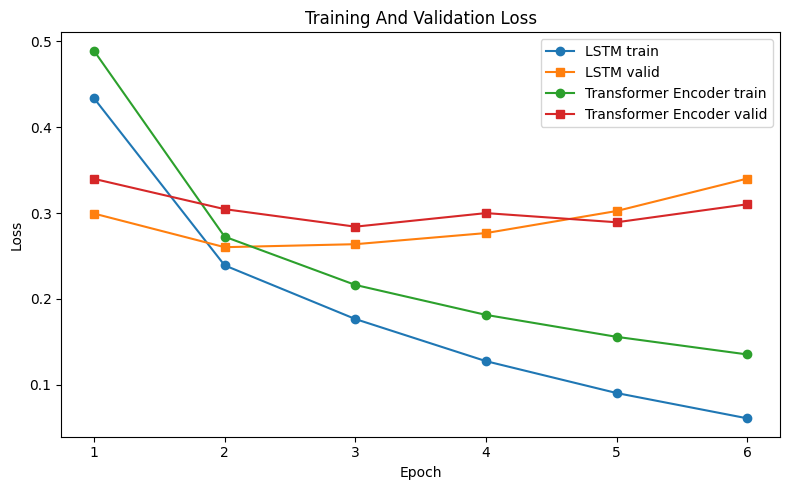

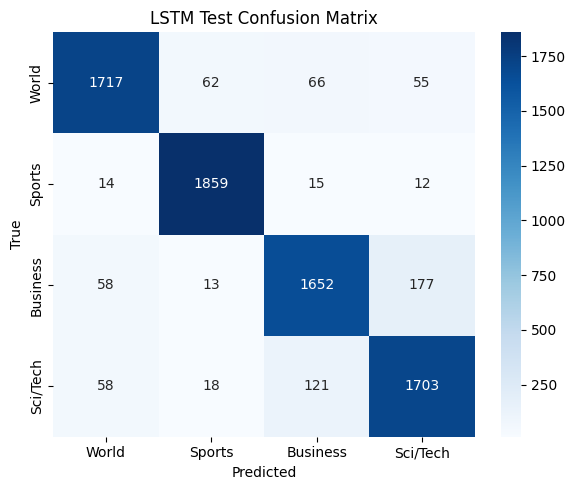

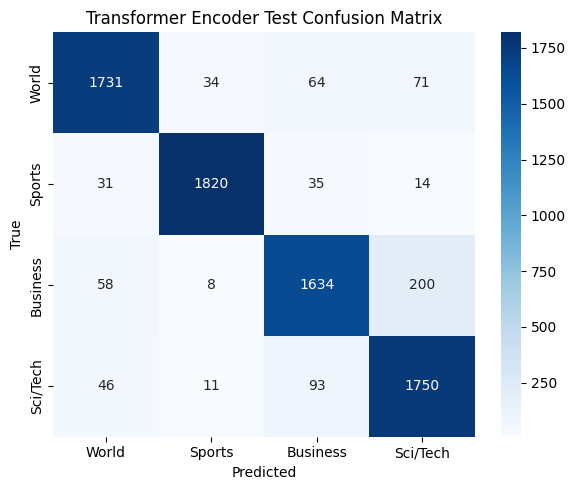

In [11]:
plot_loss_curves(
    {"LSTM": lstm_history, "Transformer Encoder": transformer_history},
    "main_loss_curves.png",
)
plot_confusion(lstm_test["labels"], lstm_test["preds"], "LSTM Test Confusion Matrix", "lstm_confusion_matrix.png")
plot_confusion(transformer_test["labels"], transformer_test["preds"], "Transformer Encoder Test Confusion Matrix", "transformer_confusion_matrix.png")

## 9. Dataset-Size Ablation

In [12]:
def make_fraction_dataset(hf_dataset, fraction: float, seed: int = SEED):
    indices = np.arange(len(hf_dataset))
    rng = np.random.default_rng(seed)
    rng.shuffle(indices)
    keep = int(len(indices) * fraction)
    return hf_dataset.select(indices[:keep].tolist())

ablation_rows = []
for fraction in [0.25, 0.50, 1.00]:
    subset = make_fraction_dataset(train_data, fraction)
    subset_loader = make_loader(subset, shuffle=True)

    set_seed(SEED)
    ab_lstm = LSTMClassifier(vocab_size).to(device)
    train_model(ab_lstm, subset_loader, valid_loader, epochs=EPOCHS, lr=LR)
    ab_lstm_valid = evaluate_model(ab_lstm, valid_loader)
    ablation_rows.append({"model": "LSTM", "train_fraction": fraction, "valid_accuracy": ab_lstm_valid["accuracy"], "valid_macro_f1": ab_lstm_valid["macro_f1"]})

    set_seed(SEED)
    ab_transformer = TransformerEncoderClassifier(vocab_size).to(device)
    train_model(ab_transformer, subset_loader, valid_loader, epochs=EPOCHS, lr=LR)
    ab_transformer_valid = evaluate_model(ab_transformer, valid_loader)
    ablation_rows.append({"model": "Transformer Encoder", "train_fraction": fraction, "valid_accuracy": ab_transformer_valid["accuracy"], "valid_macro_f1": ab_transformer_valid["macro_f1"]})

ablation_results = pd.DataFrame(ablation_rows)
save_table(ablation_results, "dataset_size_ablation.csv")
ablation_results

{'epoch': 1, 'train_loss': 0.6864368294521614, 'valid_loss': 0.46765200567245485, 'train_accuracy': 0.7372222222222222, 'valid_accuracy': 0.8368333333333333, 'train_macro_f1': 0.7365454778533937, 'valid_macro_f1': 0.8363486495678021}
{'epoch': 2, 'train_loss': 0.3409684793419308, 'valid_loss': 0.37888261596361794, 'train_accuracy': 0.8845925925925926, 'valid_accuracy': 0.87225, 'train_macro_f1': 0.8844417755923576, 'valid_macro_f1': 0.8723441797262668}
{'epoch': 3, 'train_loss': 0.23407063811796683, 'valid_loss': 0.3547468799352646, 'train_accuracy': 0.9238888888888889, 'valid_accuracy': 0.87825, 'train_macro_f1': 0.92384042281038, 'valid_macro_f1': 0.877512418819784}
{'epoch': 4, 'train_loss': 0.15964768870230076, 'valid_loss': 0.4059355175495148, 'train_accuracy': 0.9497407407407408, 'valid_accuracy': 0.8660833333333333, 'train_macro_f1': 0.9497082722954813, 'valid_macro_f1': 0.8662428320428331}
{'epoch': 5, 'train_loss': 0.10598650582852187, 'valid_loss': 0.43524797019859157, 'train

,model,train_fraction,valid_accuracy,valid_macro_f1
0,LSTM,0.25,0.871917,0.871342
1,Transformer Encoder,0.25,0.869917,0.869551
2,LSTM,0.50,0.894417,0.893958
3,Transformer Encoder,0.50,0.890083,0.889481
4,LSTM,1.00,0.908917,0.908183
5,Transformer Encoder,1.00,0.914583,0.914237


Dataset-size interpretation: the LSTM was slightly stronger at 25% and 50% of the training data, while the Transformer Encoder was stronger at 100%. This supports the original hypothesis that the LSTM can be more stable in lower-data settings, while the Transformer Encoder benefits more from the full training set. The differences are not large, so the report should describe this as a trend rather than a decisive model superiority claim.

## 10. Optional Sequence-Length Ablation

Optional extension: compare maximum sequence length 128 vs 256 while keeping the same dataset split, train-only vocabulary, optimizer family, metrics, and training budget. This section retrains both models for each sequence length and evaluates on the validation split.

In [13]:
sequence_length_rows = []
sequence_length_histories = {}

for max_len in [128, 256]:
    seq_train_loader = make_loader(train_data, shuffle=True, max_len=max_len)
    seq_valid_loader = make_loader(valid_data, max_len=max_len)

    set_seed(SEED)
    seq_lstm = LSTMClassifier(vocab_size).to(device)
    seq_lstm_history = train_model(seq_lstm, seq_train_loader, seq_valid_loader, epochs=EPOCHS, lr=LR)
    seq_lstm_valid = evaluate_model(seq_lstm, seq_valid_loader)
    sequence_length_histories[("LSTM", max_len)] = seq_lstm_history
    sequence_length_rows.append(
        {
            "model": "LSTM",
            "max_sequence_length": max_len,
            "valid_loss": seq_lstm_valid["loss"],
            "valid_accuracy": seq_lstm_valid["accuracy"],
            "valid_macro_f1": seq_lstm_valid["macro_f1"],
        }
    )

    set_seed(SEED)
    seq_transformer = TransformerEncoderClassifier(vocab_size, max_len=max_len).to(device)
    seq_transformer_history = train_model(seq_transformer, seq_train_loader, seq_valid_loader, epochs=EPOCHS, lr=LR)
    seq_transformer_valid = evaluate_model(seq_transformer, seq_valid_loader)
    sequence_length_histories[("Transformer Encoder", max_len)] = seq_transformer_history
    sequence_length_rows.append(
        {
            "model": "Transformer Encoder",
            "max_sequence_length": max_len,
            "valid_loss": seq_transformer_valid["loss"],
            "valid_accuracy": seq_transformer_valid["accuracy"],
            "valid_macro_f1": seq_transformer_valid["macro_f1"],
        }
    )

sequence_length_results = pd.DataFrame(sequence_length_rows)
save_table(sequence_length_results, "sequence_length_ablation.csv")
sequence_length_results

{'epoch': 1, 'train_loss': 0.43392158640755546, 'valid_loss': 0.299434530655543, 'train_accuracy': 0.8449444444444445, 'valid_accuracy': 0.8956666666666667, 'train_macro_f1': 0.8448797845662102, 'valid_macro_f1': 0.8951989536152236}
{'epoch': 2, 'train_loss': 0.23904752734413853, 'valid_loss': 0.2602246627608935, 'train_accuracy': 0.9189351851851851, 'valid_accuracy': 0.9105, 'train_macro_f1': 0.9188499537287421, 'valid_macro_f1': 0.9100353795626249}
{'epoch': 3, 'train_loss': 0.176487442654592, 'valid_loss': 0.26370627359549204, 'train_accuracy': 0.9401574074074074, 'valid_accuracy': 0.9110833333333334, 'train_macro_f1': 0.9401276926842324, 'valid_macro_f1': 0.9103425439799542}
{'epoch': 4, 'train_loss': 0.1273767011794779, 'valid_loss': 0.27667037077248097, 'train_accuracy': 0.9569074074074074, 'valid_accuracy': 0.91125, 'train_macro_f1': 0.9569041177119011, 'valid_macro_f1': 0.9107132353669163}
{'epoch': 5, 'train_loss': 0.09020883424800855, 'valid_loss': 0.3023857808659474, 'train_

,model,max_sequence_length,valid_loss,valid_accuracy,valid_macro_f1
0,LSTM,128,0.340210,0.911333,0.910771
1,Transformer Encoder,128,0.310273,0.911833,0.911486
2,LSTM,256,0.353489,0.906500,0.905790
3,Transformer Encoder,256,0.330411,0.906250,0.905929


Sequence-length interpretation: increasing the maximum sequence length from 128 to 256 reduced validation accuracy and macro F1 for both models in this run. The longer context therefore did not justify its additional training cost under the current model size, optimizer, and six-epoch budget. The final report should keep 128 tokens as the main controlled setting and present the 256-token result as an optional negative extension.

## 11. Failure Analysis

In [14]:
failure_df = pd.DataFrame(
    {
        "text": test_data["text"],
        "true_label": lstm_test["labels"],
        "lstm_pred": lstm_test["preds"],
        "transformer_pred": transformer_test["preds"],
        "lstm_confidence": [max(p) for p in lstm_test["probs"]],
        "transformer_confidence": [max(p) for p in transformer_test["probs"]],
    }
)
failure_df["true_label_name"] = failure_df["true_label"].map(lambda x: label_names[x])
failure_df["lstm_pred_name"] = failure_df["lstm_pred"].map(lambda x: label_names[x])
failure_df["transformer_pred_name"] = failure_df["transformer_pred"].map(lambda x: label_names[x])
failure_df["lstm_wrong"] = failure_df["lstm_pred"] != failure_df["true_label"]
failure_df["transformer_wrong"] = failure_df["transformer_pred"] != failure_df["true_label"]

both_wrong = failure_df[failure_df["lstm_wrong"] & failure_df["transformer_wrong"]].head(2)
lstm_only_wrong = failure_df[failure_df["lstm_wrong"] & ~failure_df["transformer_wrong"]].head(2)
transformer_only_wrong = failure_df[~failure_df["lstm_wrong"] & failure_df["transformer_wrong"]].head(2)

selected_failures = pd.concat([both_wrong, lstm_only_wrong, transformer_only_wrong]).head(6)
selected_failures = selected_failures[
    ["text", "true_label_name", "lstm_pred_name", "transformer_pred_name", "lstm_confidence", "transformer_confidence"]
]
save_table(selected_failures, "selected_misclassifications.csv")
selected_failures

,text,true_label_name,lstm_pred_name,transformer_pred_name,lstm_confidence,transformer_confidence
79,Live: Olympics day four Richard Faulds and Ste...,World,Sports,Sports,0.936862,0.998270
83,Intel to delay product aimed for high-definiti...,Business,Sci/Tech,Sci/Tech,0.994057,0.997693
3,Prediction Unit Helps Forecast Wildfires (AP) ...,Sci/Tech,World,Sci/Tech,0.482082,0.978537
23,Some People Not Eligible to Get in on Google I...,Sci/Tech,Business,Sci/Tech,0.816985,0.825187
15,Teenage T. rex's monster growth Tyrannosaurus ...,Sci/Tech,Sci/Tech,Business,0.442873,0.561502
20,IBM to hire even more new workers By the end o...,Sci/Tech,Sci/Tech,Business,0.835535,0.621424


Failure-analysis notes: the selected examples cover both-wrong cases, LSTM-only errors, and Transformer-only errors. Common causes include class overlap between Business and Sci/Tech, surface keywords that point to a different news section than the dataset label, and short items where the broader context is limited. The final report should discuss these examples as evidence that most remaining errors are semantic boundary cases rather than simple label-format or preprocessing failures.

## 12. Export Tables And Figures

In [15]:
export_manifest = pd.DataFrame(
    [
        {"artifact": "parameter_counts.csv", "purpose": "Trainable parameter count table"},
        {"artifact": "main_results.csv", "purpose": "Validation and final test metrics"},
        {"artifact": "dataset_size_ablation.csv", "purpose": "Required dataset-size ablation results"},
        {"artifact": "sequence_length_ablation.csv", "purpose": "Optional sequence-length ablation results"},
        {"artifact": "selected_misclassifications.csv", "purpose": "Failure-analysis examples"},
        {"artifact": "main_loss_curves.png", "purpose": "Training and validation loss curves"},
        {"artifact": "lstm_confusion_matrix.png", "purpose": "LSTM final test confusion matrix"},
        {"artifact": "transformer_confusion_matrix.png", "purpose": "Transformer Encoder final test confusion matrix"},
    ]
)
save_table(export_manifest, "artifact_manifest.csv")
export_manifest

,artifact,purpose
0,parameter_counts.csv,Trainable parameter count table
1,main_results.csv,Validation and final test metrics
2,dataset_size_ablation.csv,Required dataset-size ablation results
3,sequence_length_ablation.csv,Optional sequence-length ablation results
4,selected_misclassifications.csv,Failure-analysis examples
5,main_loss_curves.png,Training and validation loss curves
6,lstm_confusion_matrix.png,LSTM final test confusion matrix
7,transformer_confusion_matrix.png,Transformer Encoder final test confusion matrix


## 13. AI Usage Notes

- Codex was used to review the assignment, refine planning documents, and draft this notebook scaffold.
- The team must verify every generated cell by running the notebook in order and inspecting outputs.
- Any incorrect or incomplete AI output should be recorded in the AI Usage Appendix.